# Step 1: Load and Merge Data

In [1]:
import pandas as pd

scores = pd.read_csv("persuade_2.0_human_scores_demo_id_github.csv")
corpus_path = "persuade_corpus_1.0.csv"
corpus = pd.read_csv(corpus_path)
df = pd.merge(corpus, scores, on='essay_id_comp', how='inner')
print("Merged dataset shape:", df.shape)
print(df.columns)

Merged dataset shape: (284119, 22)
Index(['essay_id_comp', 'competition_set', 'full_text_x', 'discourse_id',
       'discourse_start', 'discourse_end', 'discourse_text', 'discourse_type',
       'discourse_type_num', 'full_text_y', 'holistic_essay_score',
       'word_count', 'prompt_name', 'task', 'assignment', 'source_text',
       'gender', 'grade_level', 'ell_status', 'race_ethnicity',
       'economically_disadvantaged', 'student_disability_status'],
      dtype='object')


# Step 2: Data Exploration

Unique essays: 25884


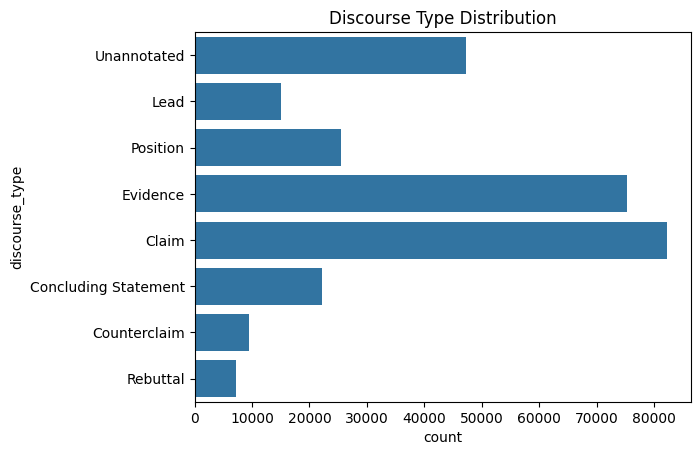

Missing values:
essay_id_comp                      0
competition_set                    0
full_text_x                        0
discourse_id                       0
discourse_start                    0
discourse_end                      0
discourse_text                     0
discourse_type                     0
discourse_type_num                 0
full_text_y                        0
holistic_essay_score               0
word_count                         0
prompt_name                        0
task                               0
assignment                         0
source_text                   158511
gender                             0
grade_level                    12382
ell_status                     12699
race_ethnicity                     0
economically_disadvantaged     56026
student_disability_status      55386
dtype: int64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Unique essays:", df['essay_id_comp'].nunique())
sns.countplot(y='discourse_type', data=df)
plt.title("Discourse Type Distribution")
plt.show()

print("Missing values:")
print(df.isnull().sum())

# Step 3: Data Engineering

In [4]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
import numpy as np
import pandas as pd

nltk.download('punkt')

essay_texts = df.groupby('essay_id_comp')['full_text_x'].first().reset_index()

essay_texts = essay_texts[essay_texts['full_text_x'].notnull()]
essay_texts = essay_texts[essay_texts['full_text_x'].apply(lambda x: isinstance(x, str))]

def safe_word_count(text):
    try:
        return len(word_tokenize(text))
    except:
        return 0

def safe_sentence_count(text):
    try:
        return len(sent_tokenize(text))
    except:
        return 0

def safe_avg_word_length(text):
    try:
        words = word_tokenize(text)
        return np.mean([len(w) for w in words]) if words else 0
    except:
        return 0

essay_texts['word_count'] = essay_texts['full_text_x'].apply(safe_word_count)
essay_texts['sentence_count'] = essay_texts['full_text_x'].apply(safe_sentence_count)
essay_texts['avg_word_length'] = essay_texts['full_text_x'].apply(safe_avg_word_length)

if 'discourse_type' in df.columns:
    discourse_counts = pd.crosstab(df['essay_id_comp'], df['discourse_type'])
    features = essay_texts.set_index('essay_id_comp').join(discourse_counts)
else:
    print("'discourse_type' not found — skipping discourse feature join.")
    features = essay_texts.set_index('essay_id_comp')

print("Feature table shape:", features.shape)
features.head()



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mimaa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


✅ Feature table shape: (25884, 12)


,full_text_x,word_count,sentence_count,avg_word_length,Claim,Concluding Statement,Counterclaim,Evidence,Lead,Position,Rebuttal,Unannotated
essay_id_comp,,,,,,,,,,,,
0000D23A521A,"Some people belive that the so called ""face"" o...",286,14,3.832168,1,1,1,3,0,1,1,0
00066EA9880D,Driverless cars are exaclty what you would exp...,681,30,4.317181,3,1,0,3,1,1,0,2
0006ED03C701,Luke's particapation in the seagoing cowboys p...,297,18,4.107744,1,1,0,1,1,1,0,2
000A58BC095E,"To Whom It May Concern,\n\nCommunity Service, ...",277,15,3.935018,3,1,0,3,1,1,0,1
000BAD50D026,Do you think students would benefit from being...,421,17,4.225653,2,1,0,2,1,1,0,0


# Step 4: Text Representation (TF-IDF + SVD)

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

tfidf = TfidfVectorizer(stop_words='english', max_features=10000)
tfidf_matrix = tfidf.fit_transform(essay_texts['full_text_x'])

svd = TruncatedSVD(n_components=100, random_state=42)
svd_matrix = svd.fit_transform(tfidf_matrix)
svd_scaled = StandardScaler().fit_transform(svd_matrix)

svd_df = pd.DataFrame(svd_scaled, index=essay_texts['essay_id_comp'])
svd_df.columns = [f'svd_{i}' for i in range(100)]

features = features.drop(columns=[col for col in features.columns if col.startswith("svd_")], errors="ignore")
features = features.join(svd_df)

print("Features shape after TF-IDF + SVD:", features.shape)


Features shape after TF-IDF + SVD: (25884, 112)


# Step 5: Target Engineering

In [6]:
from sklearn.preprocessing import LabelEncoder

features['holistic_score'] = scores.set_index('essay_id_comp').loc[features.index]['holistic_essay_score']

def to_band(score):
    if score >= 85: return 'Advanced'
    elif score >= 70: return 'Proficient'
    elif score >= 30: return 'Basic'
    else: return 'Below Basic'

features['score_band'] = features['holistic_score'].apply(to_band)
features['score_band_encoded'] = LabelEncoder().fit_transform(features['score_band'])

meta_cols = ['gender', 'grade_level', 'prompt_name', 'race_ethnicity', 'economically_disadvantaged']
for col in meta_cols:
    encoded = LabelEncoder().fit_transform(scores.set_index('essay_id_comp').loc[features.index][col])
    features[col] = encoded

# Step 6: Regression Model (Holistic Score)

In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

y = features['holistic_score']

X = features.drop(columns=[
    'holistic_score', 
    'score_band', 
    'score_band_encoded', 
    'full_text_x'
], errors='ignore')

X = X.select_dtypes(include=[np.number])

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train, y_train)

preds = reg.predict(X_test)
print("MAE:", mean_absolute_error(y_test, preds))
print("R² :", r2_score(y_test, preds))
print("RMSE:", mean_squared_error(y_test, preds))
features['predicted_score'] = reg.predict(X)

MAE: 0.42413846391593263
R² : 0.7732370760232349
RMSE: 0.30679415855354664


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_cls = features['score_band_encoded']

X_cls = features.drop(columns=[
    'holistic_score',
    'score_band',
    'score_band_encoded',
    'full_text_x',        
    'predicted_score'      
], errors='ignore')

X_cls = X_cls.select_dtypes(include=[np.number])

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_cls, y_train_cls)

y_pred_cls = clf.predict(X_test_cls)

print("Accuracy       :", accuracy_score(y_test_cls, y_pred_cls))
print("\nClassification Report:\n", classification_report(y_test_cls, y_pred_cls))
print("Confusion Matrix:\n", confusion_matrix(y_test_cls, y_pred_cls))

features['predicted_band_encoded'] = clf.predict(X_cls)

Accuracy       : 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5177

    accuracy                           1.00      5177
   macro avg       1.00      1.00      1.00      5177
weighted avg       1.00      1.00      1.00      5177

Confusion Matrix:
 [[5177]]


Z:\Softwares\py\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


# Step 7: Fairness Analysis

In [11]:
def group_mae(col):
    print(f"MAE by {col}:")
    for v in sorted(features[col].unique()):
        g = features[features[col] == v]
        print(f"{col} = {v} MAE: {mean_absolute_error(g['holistic_score'], g['predicted_score']):.3f}")

group_mae('gender')
group_mae('grade_level')
group_mae('prompt_name')
group_mae('race_ethnicity')

MAE by gender:
gender = 0 MAE: 0.228
gender = 1 MAE: 0.224
MAE by grade_level:
grade_level = 0 MAE: 0.193
grade_level = 1 MAE: 0.220
grade_level = 2 MAE: 0.267
grade_level = 3 MAE: 0.230
grade_level = 4 MAE: 0.219
grade_level = 5 MAE: 0.279
grade_level = 6 MAE: 0.209
MAE by prompt_name:
prompt_name = 0 MAE: 0.193
prompt_name = 1 MAE: 0.250
prompt_name = 2 MAE: 0.214
prompt_name = 3 MAE: 0.224
prompt_name = 4 MAE: 0.215
prompt_name = 5 MAE: 0.266
prompt_name = 6 MAE: 0.231
prompt_name = 7 MAE: 0.227
prompt_name = 8 MAE: 0.217
prompt_name = 9 MAE: 0.222
prompt_name = 10 MAE: 0.225
prompt_name = 11 MAE: 0.209
prompt_name = 12 MAE: 0.213
prompt_name = 13 MAE: 0.240
prompt_name = 14 MAE: 0.221
MAE by race_ethnicity:
race_ethnicity = 0 MAE: 0.201
race_ethnicity = 1 MAE: 0.231
race_ethnicity = 2 MAE: 0.220
race_ethnicity = 3 MAE: 0.227
race_ethnicity = 4 MAE: 0.221
race_ethnicity = 5 MAE: 0.228


# Step 8: Model Explainability (SHAP)

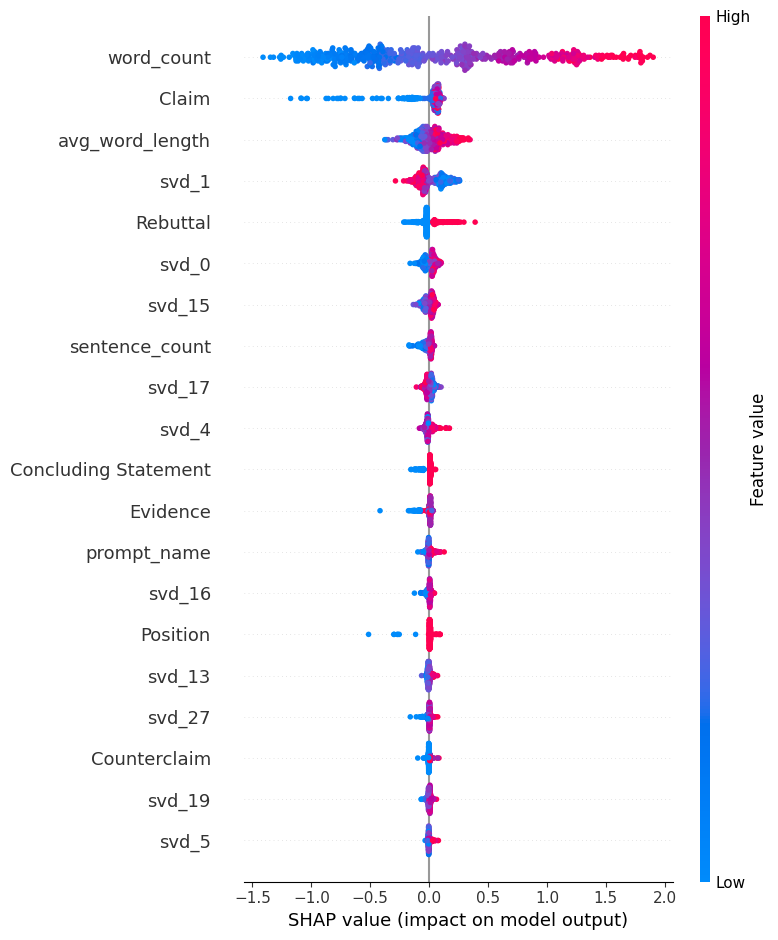

In [13]:
import shap

explainer = shap.Explainer(reg)
shap_values = explainer(X.sample(500, random_state=1))
shap.summary_plot(shap_values, X.sample(500, random_state=1))


Fairness Analysis by 'gender':


,gender,Group Size,MAE,Mean True Score,Mean Predicted Score,Prediction Gap (Pred - True)
0,0,13082,0.227857,3.426235,3.426894,0.000660
1,1,12802,0.224016,3.200672,3.210410,0.009738


['M', 'F']


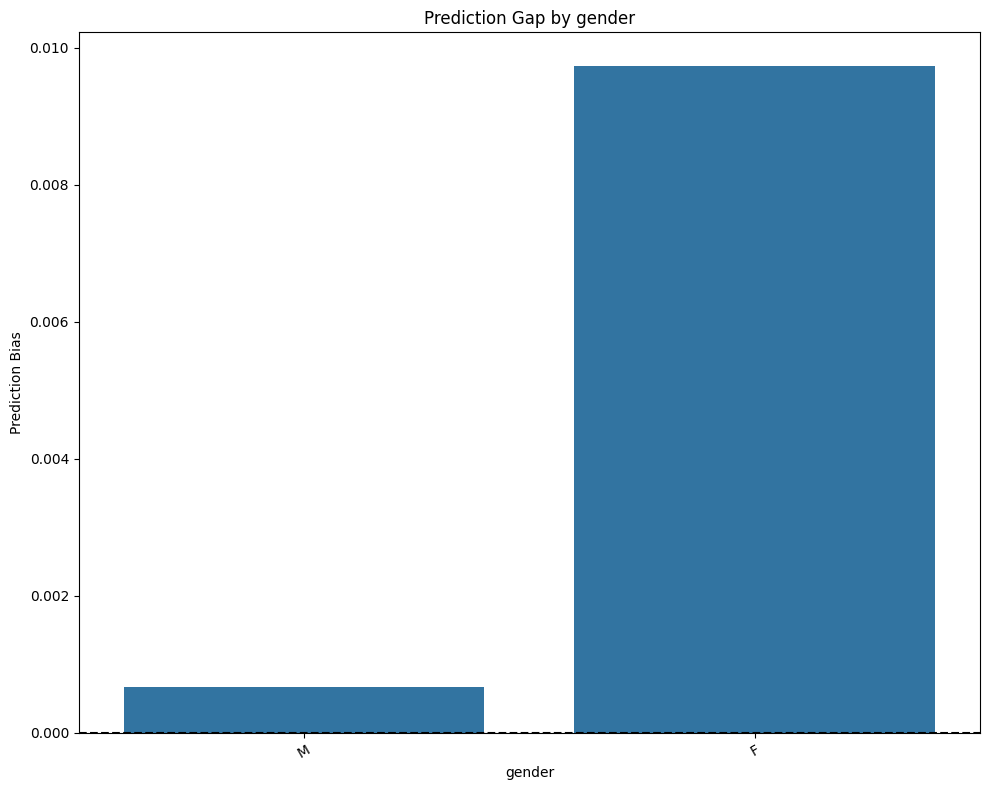


Fairness Analysis by 'grade_level':


,grade_level,Group Size,MAE,Mean True Score,Mean Predicted Score,Prediction Gap (Pred - True)
0,0,1365,0.193319,2.418315,2.449114,0.030799
1,1,9595,0.220014,3.256279,3.246467,-0.009812
2,2,2058,0.266827,3.004373,3.046526,0.042153
3,3,8230,0.230471,3.052491,3.070945,0.018454
4,4,3071,0.219085,4.605992,4.584015,-0.021977
5,5,403,0.278586,3.297767,3.438586,0.140819
6,6,1162,0.208933,3.849398,3.812840,-0.036558


[nan, 10.0, 11.0, 9.0, 12.0, 6.0, 8.0]


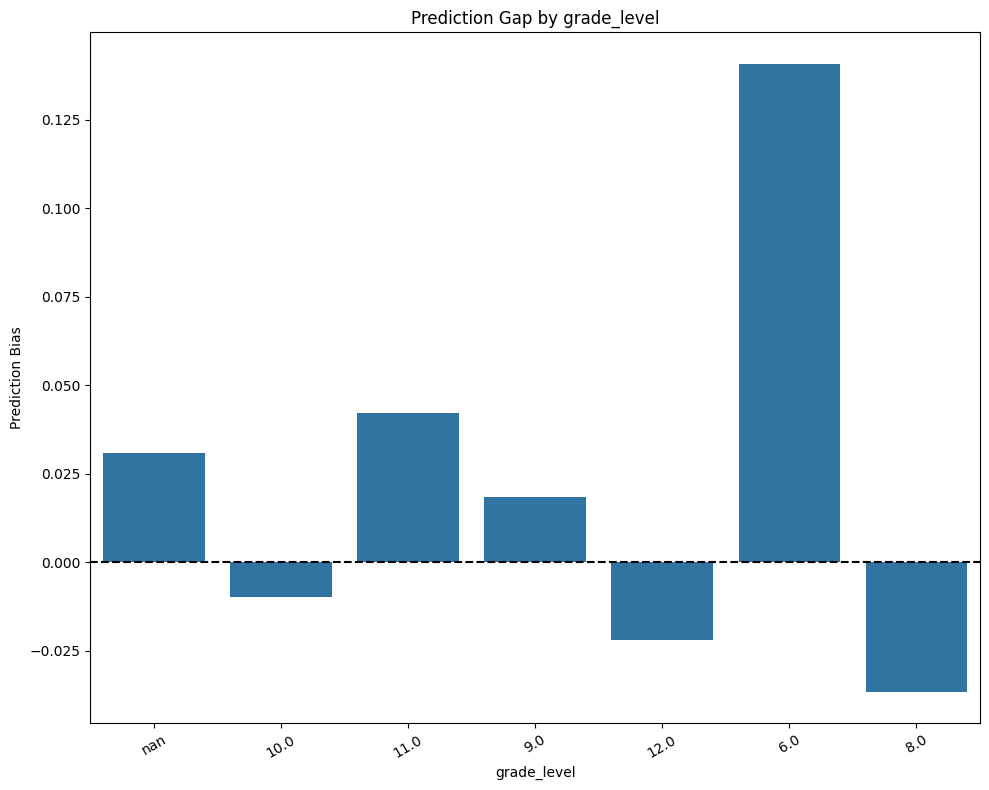


Fairness Analysis by 'race_ethnicity':


,race_ethnicity,Group Size,MAE,Mean True Score,Mean Predicted Score,Prediction Gap (Pred - True)
0,0,140,0.200786,3.021429,3.060071,0.038643
1,1,1735,0.231429,3.918156,3.902703,-0.015452
2,2,4943,0.219962,3.121181,3.150356,0.029175
3,3,6530,0.227005,3.085145,3.121342,0.036196
4,4,1021,0.221352,3.446621,3.444133,-0.002488
5,5,11515,0.227827,3.428832,3.409437,-0.019395


['Black/African American', 'White', 'Hispanic/Latino', 'Two or more races/Other', 'Asian/Pacific Islander', 'American Indian/Alaskan Native']


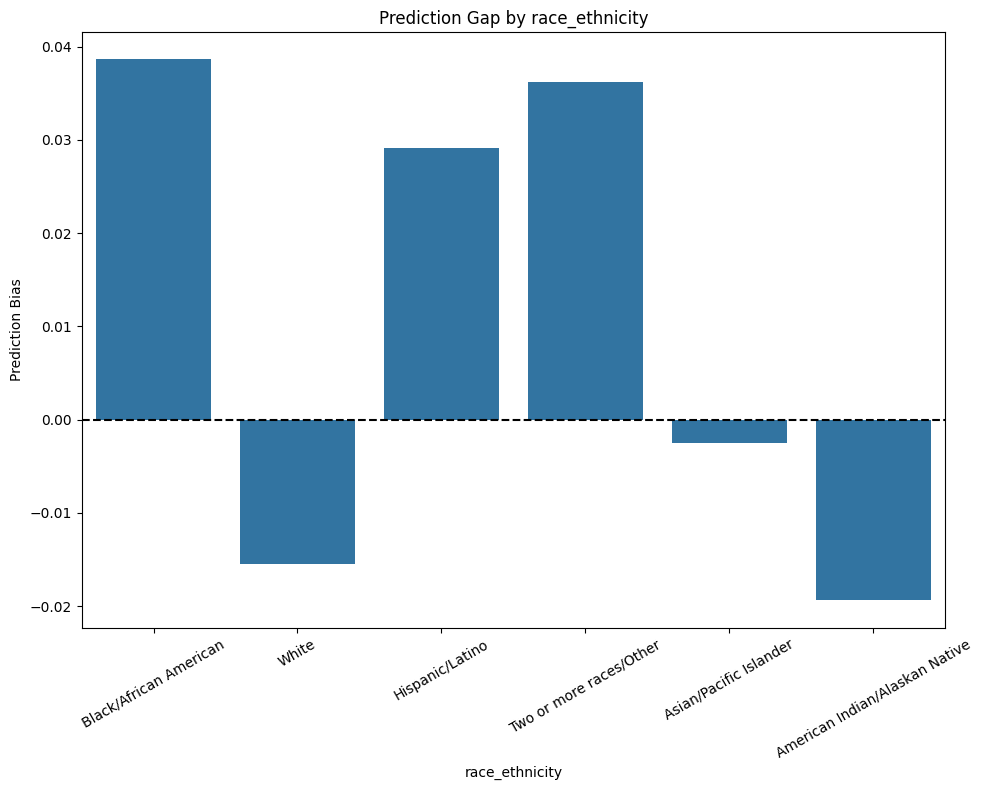


Fairness Analysis by 'economically_disadvantaged':


,economically_disadvantaged,Group Size,MAE,Mean True Score,Mean Predicted Score,Prediction Gap (Pred - True)
0,0,9600,0.218830,2.977708,3.010928,0.033220
1,1,11066,0.222161,3.648382,3.622844,-0.025539
2,2,5218,0.247122,3.226907,3.245496,0.018589


[nan, 'Not economically disadvantaged', 'Economically disadvantaged']


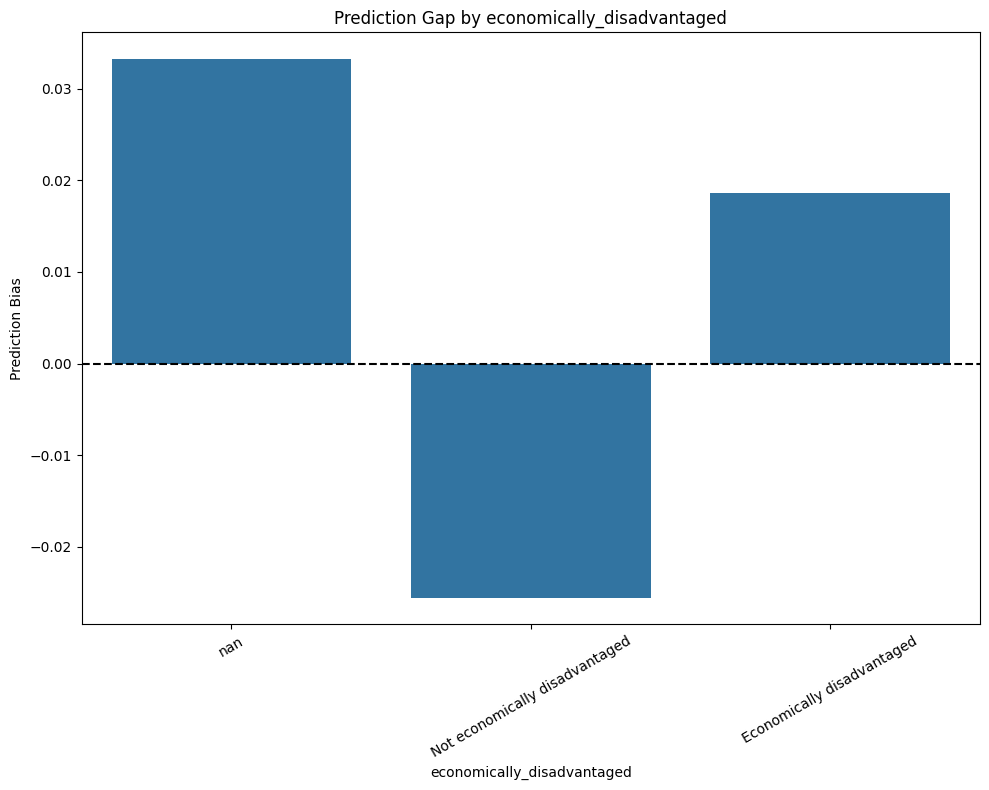


Fairness Analysis by 'prompt_name':


,prompt_name,Group Size,MAE,Mean True Score,Mean Predicted Score,Prediction Gap (Pred - True)
0,0,1365,0.193319,2.418315,2.449114,0.030799
1,1,1954,0.249759,3.099795,3.129708,0.029913
2,2,1653,0.213987,3.043557,3.010212,-0.033345
3,3,1534,0.224420,2.929596,2.932164,0.002568
4,4,2147,0.215198,4.348393,4.338915,-0.009478
5,5,2038,0.266394,3.001472,3.042959,0.041487
6,6,1869,0.230744,3.156768,3.163221,0.006453
7,7,1848,0.226867,2.882035,2.892235,0.010200
8,8,2163,0.217180,2.874711,2.899556,0.024845
9,9,1619,0.222088,2.909203,2.901384,-0.007820


['Phones and driving', 'Car-free cities', 'Summer projects', '"A Cowboy Who Rode the Waves"', 'Mandatory extracurricular activities', 'Exploring Venus', 'Facial action coding system', 'The Face on Mars', 'Community service', 'Grades for extracurricular activities', 'Driverless cars', 'Does the electoral college work?', 'Cell phones at school', 'Distance learning', 'Seeking multiple opinions']


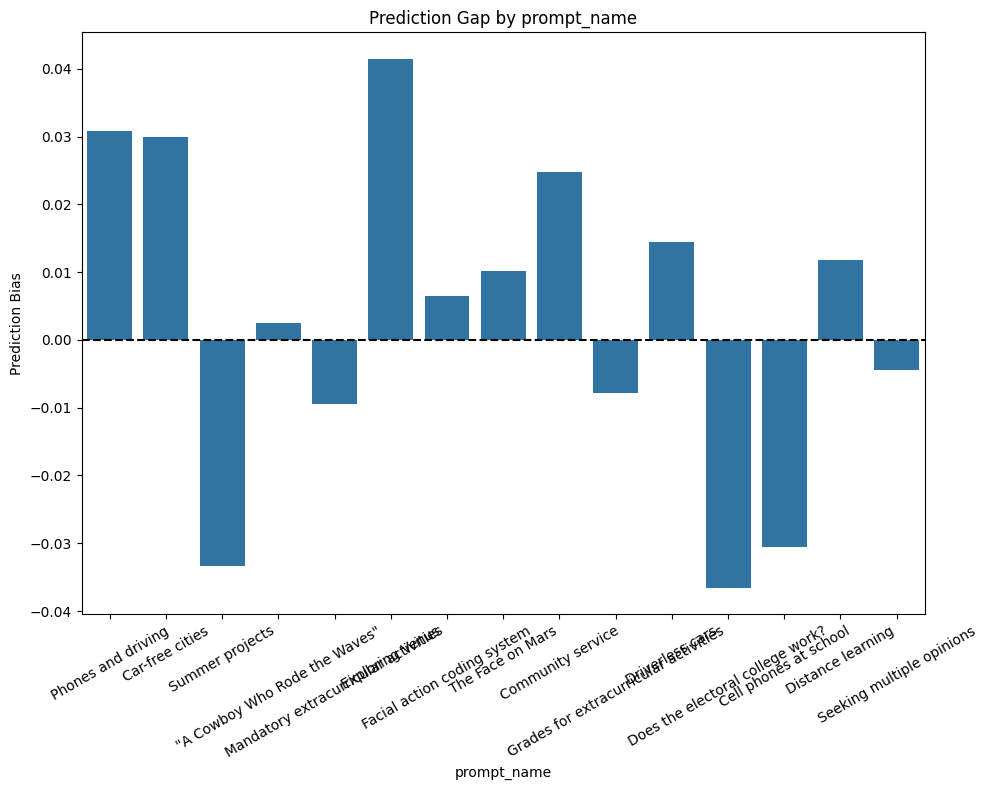

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
features['true_score'] = features['holistic_score']
features['predicted_score'] = reg.predict(X)

demographics = [
    'gender', 
    'grade_level', 
    'race_ethnicity', 
    'economically_disadvantaged',
    'prompt_name'
]

def fairness_report(df, group_col, labels):
    print(f"\nFairness Analysis by '{group_col}':")
    results = []
    
    for group in sorted(df[group_col].dropna().unique()):
        subset = df[df[group_col] == group]
        mae = mean_absolute_error(subset['true_score'], subset['predicted_score'])
        pred_mean = subset['predicted_score'].mean()
        true_mean = subset['true_score'].mean()
        gap = pred_mean - true_mean
        
        results.append({
            group_col: group,
            'Group Size': len(subset),
            'MAE': mae,
            'Mean True Score': true_mean,
            'Mean Predicted Score': pred_mean,
            'Prediction Gap (Pred - True)': gap
        })
    
    report_df = pd.DataFrame(results)
    display(report_df)
    plt.figure(figsize=(10,8))
    ax = sns.barplot(x=group_col, y='Prediction Gap (Pred - True)', data=report_df)
    print(labels)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation = 30)
    plt.title(f"Prediction Gap by {group_col}")
    plt.axhline(0, color='black', linestyle='--')
    plt.ylabel("Prediction Bias")
    plt.tight_layout()
    plt.show()

for demo_col in demographics:
    if demo_col in features.columns:
        fairness_report(features, demo_col, df[demo_col].unique().tolist())
    else:
        print(f"Column '{demo_col}' not found in dataset.")